In [213]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
plt.rcParams["text.usetex"] = False

## 1. Basic Kalman filter implementation

Consider the dynamical system
$$\begin{align}
    x_{t+1} {}={} & A x_t + G w_t,
    \\
    y_t {}={}     & C x_t + v_t.
\end{align}$$
where $A$, $G$, and $C$ are given below


In [214]:
A = np.array([[0.9, 0.15], [-0.15, 0.9]])
G = np.array([[1.2, 0.9], [0, 1]])
C = np.array([[1, 0]])

the variance-covariance matrices of $w$ and $v$ are



In [215]:
Q = 0.01 * np.array([[0.5, 0.2], [0.2, 0.5]])
R = 0.08

and all assumptions of the Gauss-Markov model are satisfied.

Implement the Kalman filter and plot the actual state, $x_t$, and estimated states $\hat{x}_{t\mid t}$, for $t=0,1,\ldots, T$ (up to a sufficiently large time $T$)

In [227]:
def measurement_update(sigma, x_estimate, y):
    x_update = x_estimate + sigma @ C.T @ np.linalg.solve(C @ sigma @ C.T + R, y - C @ x_estimate)
    sigma_update = sigma - sigma @ C.T @ np.linalg.solve(C @ sigma @ C.T + R, C @ sigma)
    return x_update, sigma_update

def time_update(sigma, x_estimate):
    x_new = A @ x_estimate
    sigma_new = A @ sigma @ A.T + G @ Q @ G.T
    return x_new, sigma_new

# This is a useful function: it plots contours of the pdf of the 2D normal distribution
def plot_2d_normal_pdf(mu, cov, alpha=1, label='None'):
    """
    Plots contours of 2D normal pdf

    :param mu: expected value
    :param cov: covariance matrix (2-by-2)
    :param alpha: transparency (alpha=1 is no transparency)
    """
    dx1 = 3.5 * np.sqrt(cov[0, 0])
    dx2 = 3.5 * np.sqrt(cov[1, 1])
    x, y = np.mgrid[mu[0]-dx1:mu[0]+dx1:.05, mu[1]-dx2:mu[1]+dx2:.05]
    pos = np.dstack((x, y))
    z = stats.multivariate_normal.pdf(pos, mu, cov)
    plt.contour(x, y, z, levels=10, alpha=alpha, label=label)

In [230]:

def plot_covariance_ellipse(mu, cov, n_std=2, **kwargs):
    """
    Plot covariance ellipse for 2D Gaussian.
    
    mu: mean (2,)
    cov: covariance (2x2)
    n_std: number of standard deviations
    """

    # Eigen decomposition
    eigenvals, eigenvecs = np.linalg.eigh(cov)

    # Sort eigenvalues largest first
    order = eigenvals.argsort()[::-1]
    eigenvals = eigenvals[order]
    eigenvecs = eigenvecs[:, order]

    # Compute ellipse angle
    angle = np.degrees(np.arctan2(eigenvecs[1,0], eigenvecs[0,0]))

    # Axis lengths
    width = 2 * n_std * np.sqrt(eigenvals[0])
    height = 2 * n_std * np.sqrt(eigenvals[1])

    ellipse = plt.matplotlib.patches.Ellipse(
        xy=mu,
        width=width,
        height=height,
        angle=angle,
        fill=False,
        **kwargs
    )

    plt.gca().add_patch(ellipse)

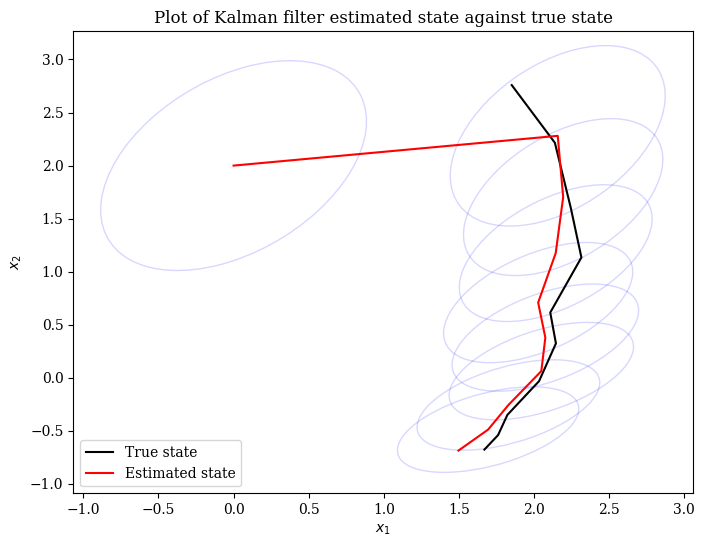

In [232]:
x0_mean = np.array([0, 2])
x0_var = np.array([[0.9, 0.4], [0.4, 0.3]])
N = 10

x_0 = np.random.multivariate_normal(x0_mean, x0_var)

x_t = np.zeros((2, N))
y_t = np.zeros((1, N))
x_estimate = np.zeros((2, N))

sigma = x0_var

x_t = np.zeros((2, N))
x_t[:, 0] = x_0
x_estimate[:, 0] = x0_mean

plt.figure(figsize=(8, 6))

for t in range(N - 1):

    w = np.random.multivariate_normal(np.array([0, 0]), Q)
    v = np.random.normal(0, np.sqrt(R))

    y_t[:, t] = C @ x_t[:, t] + v

    x_update, sigma = measurement_update(sigma, x_estimate[:, t], y_t[:, t])

    x_estimate[:, t + 1], sigma = time_update(sigma, x_update)
    
    # True state.
    x_t[:, t + 1] = A @ x_t[:, t] + G @ w

    plot_covariance_ellipse(x_estimate[:, t], sigma, 3, edgecolor='blue', alpha=0.05 + (0.95 / (N - 1)))

plt.plot(x_t[0, :], x_t[1, :], color='k', label='True state')
plt.plot(x_estimate[0, :], x_estimate[1, :], color='r', label='Estimated state')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Plot of Kalman filter estimated state against true state')
plt.legend()
plt.show()

## 2. Kalman filter design

Consider a dynamical system with state $x_t\in{\rm I\!R}^3$ with 
$$x_{t+1} = \begin{bmatrix}0.7 & 0.1 & -0.1 \\ 0.2 & 0.6 & 1 \\ 1 & 0.1 & 0.1\end{bmatrix}x_t + \begin{bmatrix}d_t \\ 0 \\ 0\end{bmatrix} + w_t,$$
where $d_t$ is an unknown bias, and $w_t\sim \mathcal{N}(0, Q)$ is an iid process noise with covariance matrix 
$$Q = \begin{bmatrix}0.1 & 0.01 & 0\\0.01 & 0.05 & 0\\0 & 0 & 0.05\end{bmatrix}.$$
The system is equipped with two sensors for measuring the first coordinate of the state, each with an additive iid measurement noise with covariance $\sigma_1^2=\sigma_2^2=0.012$. A third sensor is used to measure $x_2 + x_3$ with additive iid measurement noise $\sigma_3^2=0.022$, that is,
$$y_{3,t} = x_{2,t} + x_{3,t} + v_{3,t},$$
where $x_{2,t}$ and $x_{3, t}$ are the second and third coordinates of the state vector, and $v_{3, t} \sim \mathcal{N}(0, \sigma_3^2)$. A fourth sensor is used to measure the difference $x_2 - x_3$ with additive iid measurement noise $\sigma_4^2=0.019$. The measurement noises $v_1, v_2, v_3, v_4$ are independent from one another.

**Your task:** implement a Kalman filter for this system and show plots similar to the ones

In [218]:
# Your code goes here